# Data Analysis

In [127]:
import duckdb
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [36]:
# Setup logger

logging.basicConfig(
    filename='./logs/data_analysis.log',
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='w'
)
logger = logging.getLogger(__name__)

## Database Querying

In [37]:
# Query the database

try:
    
    # Establish DuckDB connection
    con = duckdb.connect(database='./sp500.duckdb', read_only=False)
    logger.info("Connected to DuckDB instance")

    # Query the sp500 Database
    company_table = con.execute("""
        SELECT
            c.Symbol, c.Shortname, c.Sector, c.Industry,
            e.totalEsg, e.environmentScore, e.socialScore, e.governanceScore, e.percentile, e.beta, e.highestControversy, e.overallRisk,
            AVG(s.Open) AS avg_open, AVG(s.Close) AS avg_close, AVG(s.High) AS avg_high, AVG(s.Low) AS avg_low, AVG(s.Volume) AS avg_volume, AVG((s.Close - s.Open) / s.Open) AS avg_daily_return, STDDEV(s.Close) AS price_volatility
        FROM companies c
        LEFT JOIN esg e
            ON c.Symbol = e.Symbol
        LEFT JOIN stocks s
            ON c.Symbol = s.Symbol
        INNER JOIN constituents cn
            ON c.Symbol = cn.Symbol
        GROUP BY
            c.Symbol, c.Shortname, c.Sector, c.Industry,
            e.totalEsg, e.environmentScore, e.socialScore, e.governanceScore, e.percentile, e.beta, e.highestControversy, e.overallRisk
        ORDER BY avg_close DESC;
    """).df()
    logger.info("Query complete")

    # Close DuckDB connection
    con.close()
    logger.info("Closed DuckDB connection")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

In [38]:
company_table.head()


,Symbol,Shortname,Sector,Industry,totalEsg,environmentScore,socialScore,governanceScore,percentile,beta,highestControversy,overallRisk,avg_open,avg_close,avg_high,avg_low,avg_volume,avg_daily_return,price_volatility
0,MTD,"Mettler-Toledo International, I",Healthcare,Diagnostics & Research,13.10,1.00,7.41,4.69,6.93,1.139,0.0,5,644.892789,645.048911,652.233365,637.424992,1.623200e+05,0.000650,469.949198
1,EQIX,"Equinix, Inc.",Real Estate,REIT - Specialty,13.88,3.44,5.31,5.13,8.50,0.700,1.0,5,426.004031,426.076441,430.665350,421.111144,6.753230e+05,0.000431,254.737572
2,TDG,Transdigm Group Incorporated,Industrials,Aerospace & Defense,38.72,12.01,17.71,9.00,90.45,1.410,2.0,10,394.221516,394.298474,398.558856,389.727444,4.060174e+05,0.000629,318.809429
3,NFLX,"Netflix, Inc.",Communication Services,Entertainment,16.41,0.09,7.31,9.01,15.33,1.262,2.0,9,232.776050,232.850524,236.217270,229.286021,1.664855e+07,0.000911,210.464293
4,FDS,FactSet Research Systems Inc.,Financial Services,Financial Data & Stock Exchanges,18.37,4.32,8.75,5.30,21.85,0.748,1.0,6,226.933893,227.038344,229.227513,224.720395,3.067631e+05,0.000656,129.810908


In [39]:
company_table.isna().sum()

Symbol                  0
Shortname               0
Sector                  0
Industry                0
totalEsg               69
environmentScore       69
socialScore            69
governanceScore        69
percentile             69
beta                   69
highestControversy     69
overallRisk            69
avg_open              310
avg_close             310
avg_high              310
avg_low               310
avg_volume            310
avg_daily_return      310
price_volatility      310
dtype: int64

In [45]:
# Data cleaning - drop NAs

company_table = company_table.dropna()

new_len = len(company_table)
print("Rows:", new_len)

Rows: 142


The stocks table has lots of missing fields; the output company table has 66% NA values for the stock fields. Dropping the NAs hurts this analysis but does not prevent the development of a model. The cleaned table has 142 entries.

## Modeling

In [ ]:
# Data cleaning for modeling

# Drop unnecessary columns
company_table_modeling = company_table.drop(columns=["Symbol", "Shortname", "percentile"])

# Drop dummy variables
company_table_modeling = pd.get_dummies(company_table_modeling, columns=["Sector", "Industry"], drop_first=True)

# Separate features and target variable
X = company_table_modeling.drop("avg_daily_return", axis=1)
y = company_table_modeling["avg_daily_return"]

logger.info("Modeling preprocessing complete")

In [65]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=45)

logger.info("Perform train/test split")

In [66]:
# Initialize Random Forest object
rf = RandomForestRegressor(n_jobs=-1, random_state=45)

# Define parameters
params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Set up Grid Search
grid = GridSearchCV(rf, params, cv=3, n_jobs=-1)

In [ ]:
# Fit the model 

grid.fit(X_train, y_train)

logger.info("Random Forest fitting complete")

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=45),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]})

In [73]:
# Explore the best model

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
0.19695408034221887


In [86]:
# Predict on the test set and evaluate performance

pred = grid.best_estimator_.predict(X_test)

mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

logger.info("Evaluate on the test set")

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 4.4127229137494874e-08
R2 Score: 0.25071271139634355


In [93]:
# Determine feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid.best_estimator_.feature_importances_}
)

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance.head(15))

logger.info("Determine feature importance")

                       Feature  Importance
12            price_volatility    0.253103
1             environmentScore    0.158964
4                         beta    0.157933
58    Industry_Medical Devices    0.052349
21           Sector_Technology    0.043907
0                     totalEsg    0.040898
11                  avg_volume    0.036766
2                  socialScore    0.036315
37             Industry_Copper    0.025515
35  Industry_Computer Hardware    0.022024
3              governanceScore    0.020398
6                  overallRisk    0.019621
9                     avg_high    0.019335
7                     avg_open    0.016515
8                    avg_close    0.014114


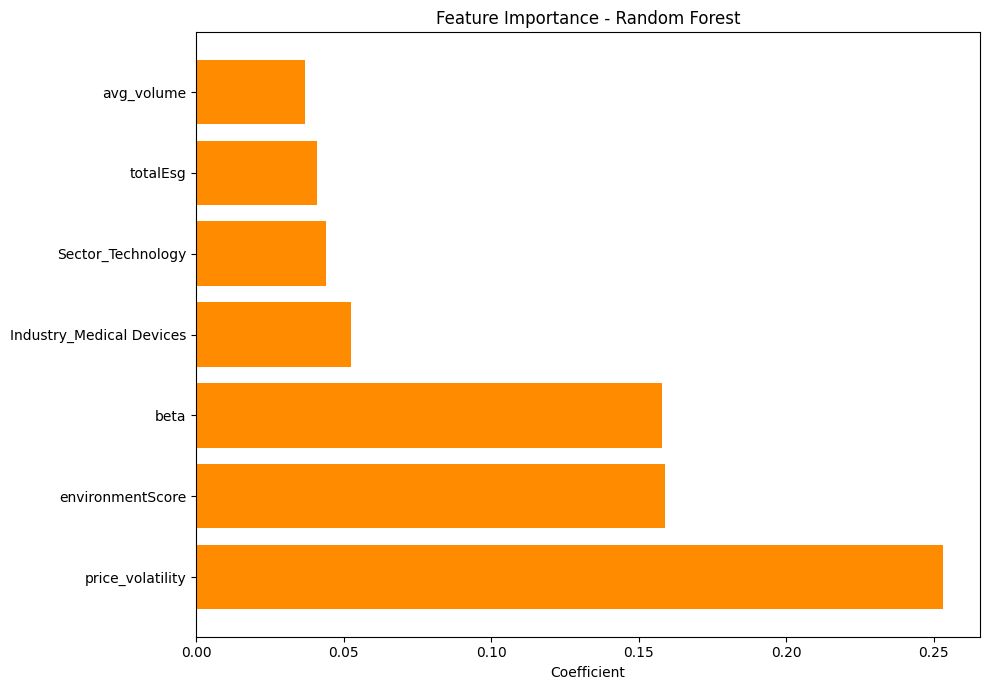

In [106]:
# Visualize feature importance

top_features = feature_importance.head(7)

plt.figure(figsize=(10,7))
plt.barh(top_features['Feature'], top_features['Importance'], color="darkorange")
plt.xlabel("Coefficient")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.savefig("./graphics/feature_importance.png")
plt.show()


### Analysis Rationale

The analysis process was guided by the goal of understanding how company characteristics and ESG factors relate to stock performance across S&P 500 firms. The target variable selected was avg_daily_return, as it provides a normalized measure of performance that allows for meaningful comparison across companies with different price levels. This choice reflects a focus on relative returns rather than absolute price movements, which are less informative in cross-sectional analysis. A Random Forest regression model was selected due to its ability to capture non-linear relationships and interactions between variables without requiring strong parametric assumptions. This is particularly important given the complexity of financial markets and the potential interplay between ESG scores, risk metrics, and sector classifications. Additionally, Random Forest models are robust to overfitting and can handle a mix of feature types effectively, making them well-suited for this dataset.

To improve model performance and ensure appropriate parameter selection, a grid search  was implemented to evaluate combinations of hyperparameters such as the number of trees and maximum tree depth. This process helps identify a model configuration that generalizes well to unseen data rather than relying on arbitrary parameter choices. Model performance was evaluated using the R² metric, which measures the proportion of variance in average daily returns explained by the model. This metric was chosen because it provides an interpretable measure of explanatory power in a regression context. While R² does not capture all aspects of predictive performance, it offers a useful baseline for assessing how well the selected features account for variation in stock returns. 

## Visualization

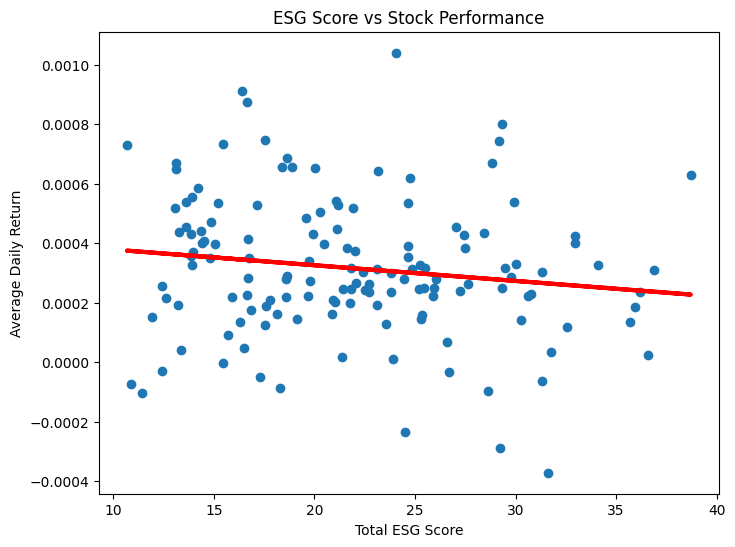

In [140]:
# Visualize ESG Scores vs Performance

plt.figure(figsize=(8, 6))

z = np.polyfit(company_table["totalEsg"], company_table["avg_daily_return"], 1)
p = np.poly1d(z)

plt.scatter(company_table["totalEsg"], company_table["avg_daily_return"])
plt.plot(company_table["totalEsg"], p(company_table["totalEsg"]), color="Red", linewidth=3)
plt.xlabel("Total ESG Score")
plt.ylabel("Average Daily Return")
plt.title("ESG Score vs Stock Performance")
plt.savefig("./graphics/esg_performance.png")
plt.show()

logger.info("Visualize ESG scores vs performance")

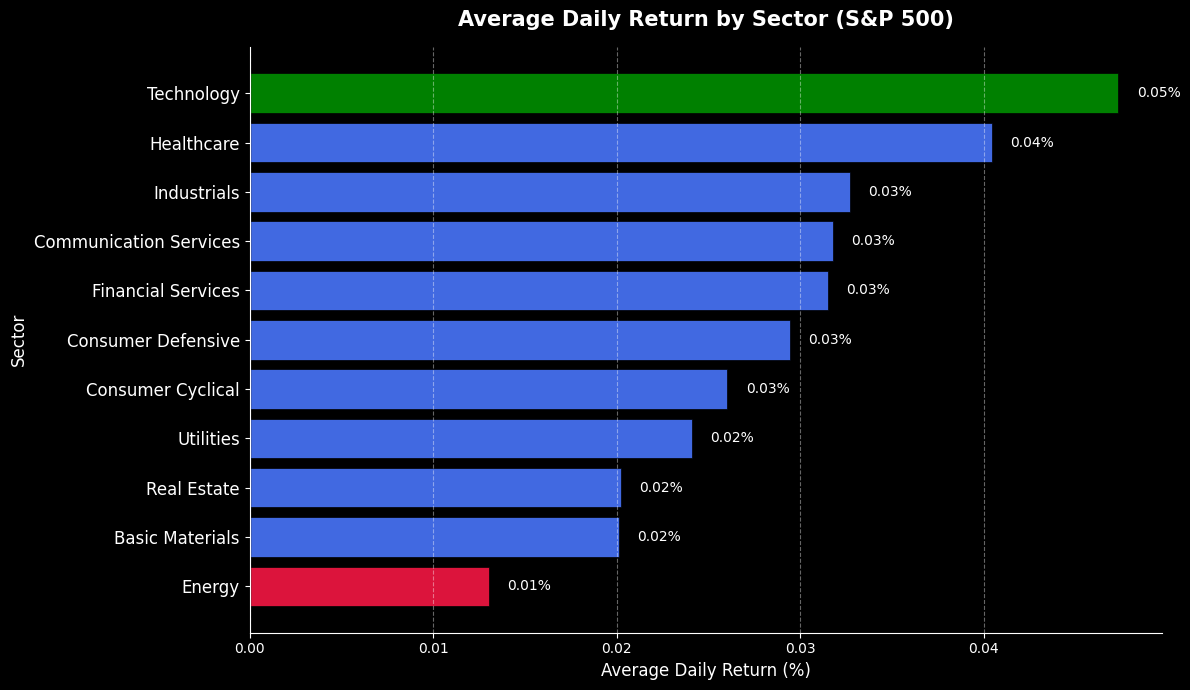

In [166]:
# Visualizer performance by sector

sector_performance = company_table.groupby("Sector")["avg_daily_return"].mean().sort_values()
sector_performance_pct = sector_performance * 100

plt.figure(figsize=(12, 7))

colors = ['RoyalBlue'] * len(sector_performance_pct)
colors[0] = 'Crimson'
colors[-1] = 'Green'

bars = plt.barh(sector_performance_pct.index, sector_performance_pct.values, color=colors, edgecolor='black', linewidth=0.5)

plt.title("Average Daily Return by Sector (S&P 500)", fontsize=15, pad=15, weight='bold')
plt.xlabel("Average Daily Return (%)", fontsize=12)
plt.ylabel("Sector", fontsize=12)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height() / 2, f"{width:.2f}%", va='center', fontsize=10)

plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=10)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("./graphics/sector_performance.png")
plt.show()

logger.info("Visualize performance by sector")

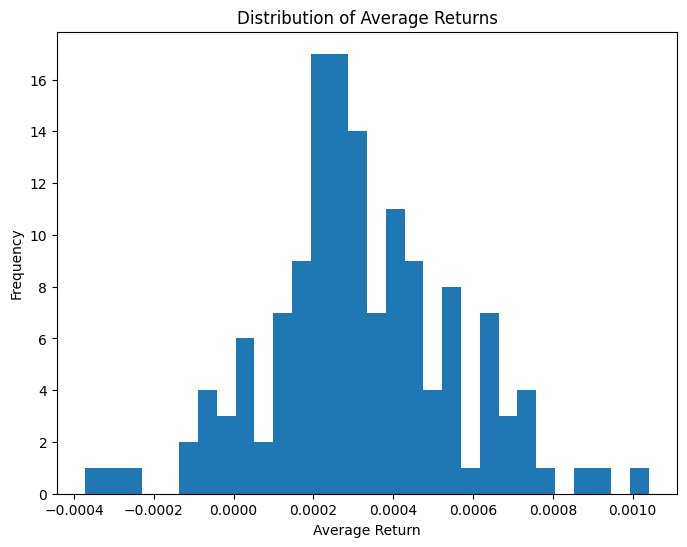

In [142]:
# Visualize distribution of returns

plt.figure(figsize=(8, 6))
plt.hist(company_table["avg_daily_return"], bins=30)
plt.title("Distribution of Average Returns")
plt.xlabel("Average Return")
plt.ylabel("Frequency")
plt.savefig("./graphics/average_returns.png")
plt.show()

logger.info("Visualize distribution of returns")

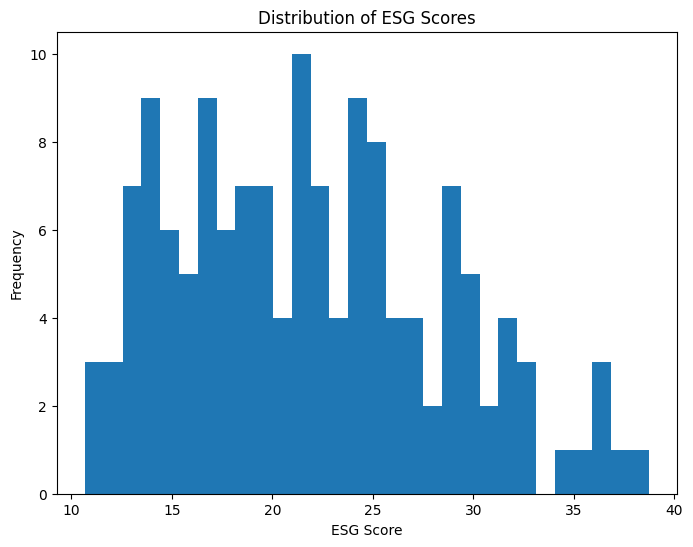

In [143]:
# Visualize distribution of ESG scores

plt.figure(figsize=(8, 6))
plt.hist(company_table["totalEsg"], bins=30)
plt.title("Distribution of ESG Scores")
plt.xlabel("ESG Score")
plt.ylabel("Frequency")
plt.savefig("./graphics/esg_distribution.png")
plt.show()

logger.info("Visualize distribution of ESG scores")

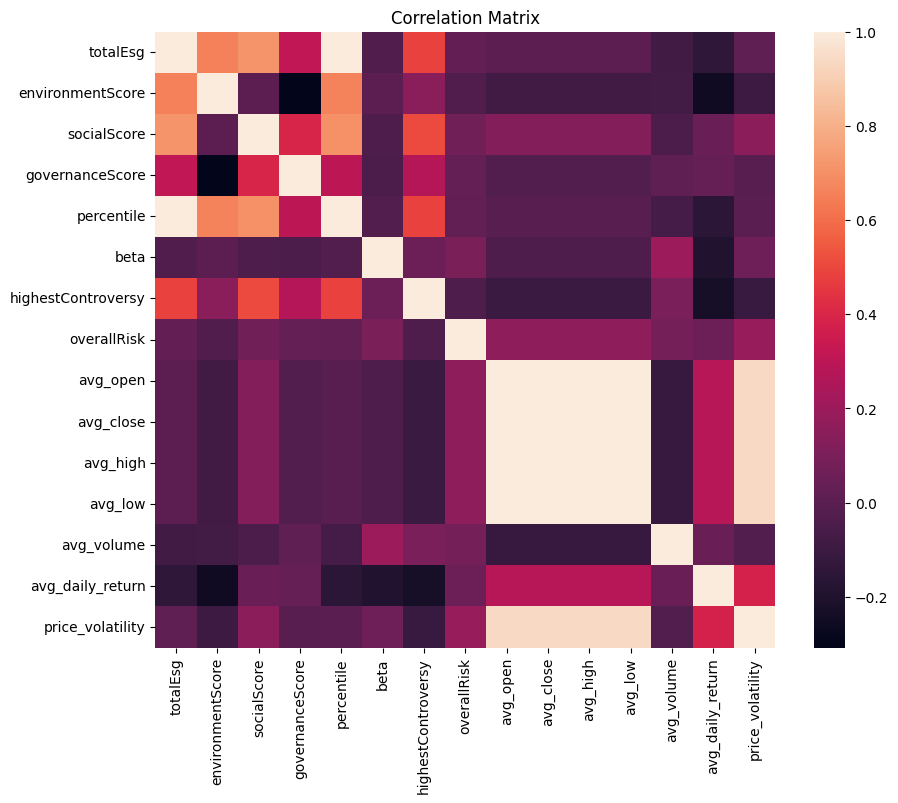

In [144]:
# Heatmap of features

plt.figure(figsize=(10, 8))
sns.heatmap(company_table.corr(numeric_only=True), annot=False)
plt.title("Correlation Matrix")
plt.savefig("./graphics/feature_heatmap.png")
plt.show()

logger.info("Plot heatmap of features")

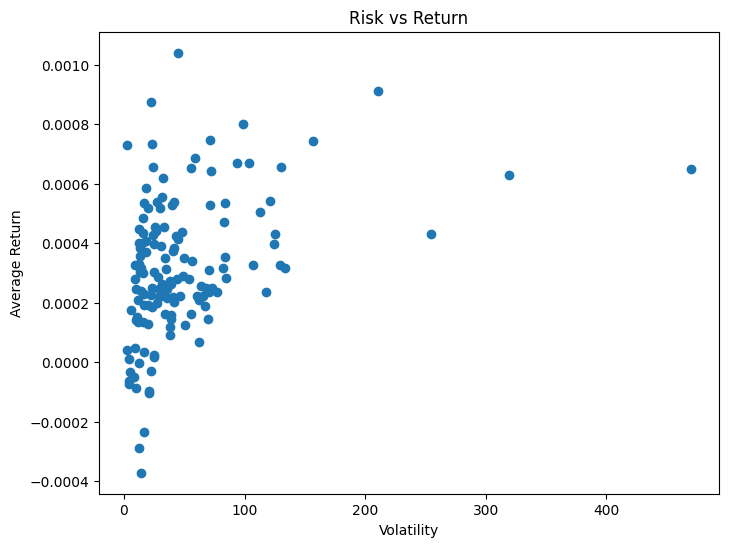

In [145]:
# Visualize volatility vs return

plt.figure(figsize=(8, 6))
plt.scatter(company_table["price_volatility"], company_table["avg_daily_return"])
plt.xlabel("Volatility")
plt.ylabel("Average Return")
plt.title("Risk vs Return")
plt.savefig("./graphics/risk_return.png")
plt.show()

logger.info("Visualize risk vs return")

### Visualization Rationale

The visualization process was designed to highlight key relationships within the dataset while being appealing and understandable for a general audience. A combination of visualization types were selected to capture different analytical perspectives. A plot of feature importance was used to identify which variables most strongly influence model predictions, providing insight into the relative impact of ESG metrics, risk factors, and company characteristics. Various other plots were implemented to examine relationships between variables such as ESG scores and average returns or risk. Plots of variable distributions were used to understand the spread key variables like returns and ESG scores. Additionally, a correlation heatmap was included to provide a high-level view of relationships across all numerical features. Together, these visualization types support both exploratory analysis and the display of meaningful insights.

The sector-level visualization was specifically designed to provide insight into how performance varies across different areas of the market. By aggregating average daily returns by sector and displaying them in a horizontal bar chart, the visualization enables a comparison of stocker performance across industries. This visualization helps contextualize individual company results within broader market segments, highlighting which sectors contribute most to overall returns. Overall, it takes a high-level view to display macro market trends, reinforcing the importance of sector in understanding stock performance within the S&P 500.